In [1]:
from pathlib import Path

import torch

from rtnls_inference import (
    HeatmapRegressionEnsemble,
    SegmentationEnsemble,
)

## Segmentation of preprocessed images

Here we segment images preprocessed using 0_preprocess.ipynb


In [2]:
ds_path = Path("../samples/fundus")

# input folders. these are the folders where we stored the preprocessed images
rgb_path = ds_path / "rgb"
ce_path = ds_path / "ce"

# these are the output folders for:
av_path = ds_path / "av"                # artery-vein segmentations
discs_path = ds_path / "discs"          # optic disc segmentations
overlays_path = ds_path / "overlays"    # optional overlay visualizations

device = torch.device("cuda:0")         # device to use for inference

In [3]:
rgb_paths = sorted(list(rgb_path.glob("*.png")))
ce_paths = sorted(list(ce_path.glob("*.png")))
paired_paths = list(zip(rgb_paths, ce_paths))

In [4]:
paired_paths[0]         # important to make sure that the paths are paired correctly

(PosixPath('../samples/fundus/rgb/CHASEDB1_08L.png'),
 PosixPath('../samples/fundus/ce/CHASEDB1_08L.png'))

### Artery-vein segmentation


In [5]:
av_ensemble = SegmentationEnsemble.from_release("av_july24_v2.pt").to(device)
av_ensemble.predict_preprocessed(paired_paths, dest_path=av_path, num_workers=2)

100%|██████████| 1/1 [00:09<00:00,  9.36s/it]


### Disc segmentation


In [6]:
disc_ensemble = SegmentationEnsemble.from_release("disc_july24.pt").to(device)
disc_ensemble.predict_preprocessed(
    paired_paths, dest_path=discs_path, num_workers=2
)

100%|██████████| 1/1 [00:02<00:00,  2.80s/it]


### Fovea detection


In [7]:
fovea_ensemble = HeatmapRegressionEnsemble.from_release("fovea_july24.pt").to(device)
# note: this model does not use contrast enhanced images
df = fovea_ensemble.predict_preprocessed(paired_paths, num_workers=2)
df.columns = ["mean_x", "mean_y"]
df.to_csv(ds_path / "fovea.csv")

100%|██████████| 1/1 [00:02<00:00,  2.35s/it]


In [8]:
df

,mean_x,mean_y
CHASEDB1_08L,963.0,553.0
CHASEDB1_12R,101.0,633.0
DRIVE_22,487.0,525.0
DRIVE_40,503.0,525.0
HRF_04_g,551.0,533.0
HRF_07_dr,545.0,533.0


### Plotting the retinas (optional)

This will only work if you ran all the models and stored the outputs using the same folder/file names as above


In [6]:
from vascx.utils.loader import RetinaLoader
from rtnls_enface.utils.plotting import plot_gridfns

loader = RetinaLoader.from_folder(ds_path)

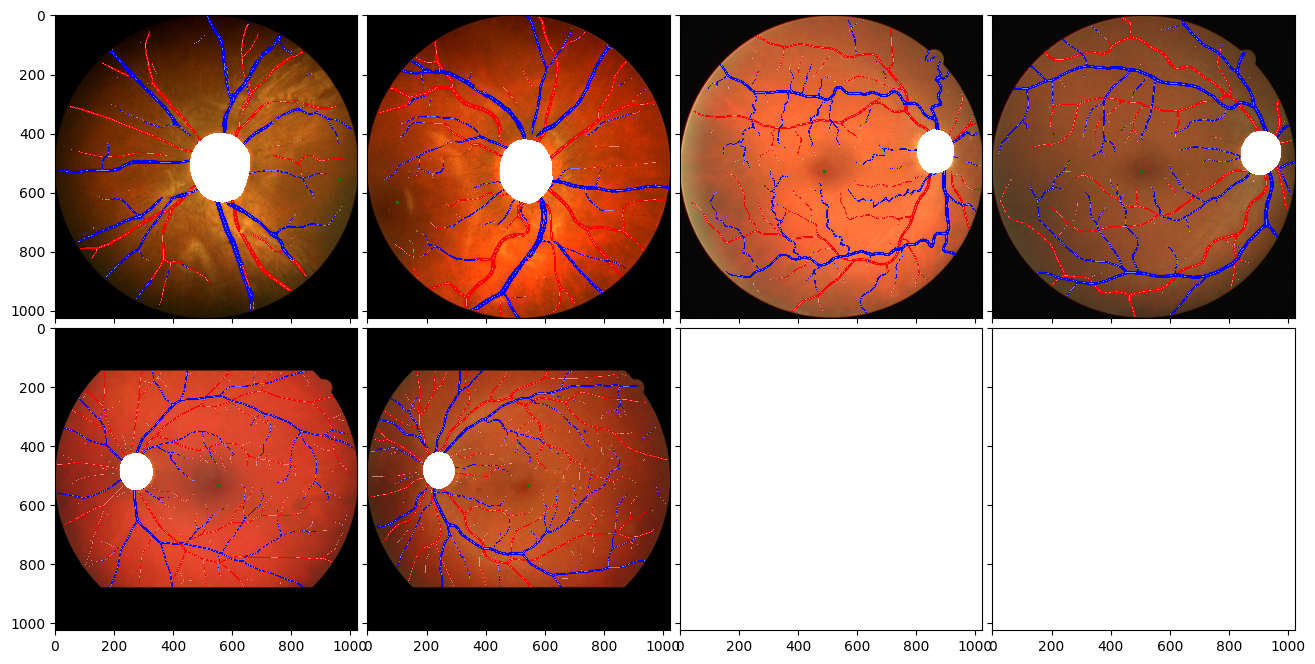

In [7]:
plot_gridfns([ret.plot for ret in loader[:6]])

### Storing visualizations (optional)


In [8]:
if not overlays_path.exists():
    overlays_path.mkdir()
for ret in loader:
    fig, _ = ret.plot()
    fig.savefig(overlays_path / f"{ret.id}.png", bbox_inches="tight", pad_inches=0)